In [1]:

import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patheffects as pe
import pandas as pd
import seaborn as sns
from PIL import Image
from torchvision import transforms, models
from torchvision.models.segmentation import deeplabv3_resnet50

import json
import requests
import zipfile
import torch
import math
import io


In [2]:
# link = "128.32.162.150/bdd100k/bdd100k_images_100k.zip"

In [3]:
from glob import iglob




json_folder = "/Users/amannindra/Projects/Auto/100k_json"
image_folder = "/Users/amannindra/Projects/Auto/100k_images"

json_test = os.path.join(json_folder, os.path.join(json_folder, "test"))
print(f"JSON test: {json_test}")
json_train = os.path.join(json_folder, os.path.join(json_folder), 'train')
print(f"JSON train: {json_train}")
json_val = os.path.join(json_folder, os.path.join(json_folder), 'test')
print(f"JSON val: {json_val}")

image_test = os.path.join(image_folder, os.path.join(image_folder), 'test')
print(f"Image test: {image_test}")
image_train = os.path.join(image_folder,  os.path.join(image_folder), 'train')
print(f"Image train: {image_train}")
image_val = os.path.join(image_folder, os.path.join(image_folder), 'val')
print(f"Image val: {image_val}")


if os.path.exists(json_test):
    print(f"Folder {json_test} already exists")
else:
    print(f"Folder {json_test} does not exist")
if os.path.exists(image_test):
    print(f"Folder {image_test} already exists")
else:
    print(f"Folder {image_test} does not exist")
if os.path.exists(json_train):
    print(f"Folder {json_train} already exists")
else:
    print(f"Folder {json_train} does not exist")
if os.path.exists(image_train):
    print(f"Folder {image_train} already exists")
else:
    print(f"Folder {image_train} does not exist")
if os.path.exists(json_val):
    print(f"Folder {json_val} already exists")
else:
    print(f"Folder {json_val} does not exist")
if os.path.exists(image_val):
    print(f"Folder {image_val} already exists")

JSON test: /Users/amannindra/Projects/Auto/100k_json/test
JSON train: /Users/amannindra/Projects/Auto/100k_json/train
JSON val: /Users/amannindra/Projects/Auto/100k_json/test
Image test: /Users/amannindra/Projects/Auto/100k_images/test
Image train: /Users/amannindra/Projects/Auto/100k_images/train
Image val: /Users/amannindra/Projects/Auto/100k_images/val
Folder /Users/amannindra/Projects/Auto/100k_json/test already exists
Folder /Users/amannindra/Projects/Auto/100k_images/test already exists
Folder /Users/amannindra/Projects/Auto/100k_json/train already exists
Folder /Users/amannindra/Projects/Auto/100k_images/train already exists
Folder /Users/amannindra/Projects/Auto/100k_json/test already exists
Folder /Users/amannindra/Projects/Auto/100k_images/val already exists


In [4]:
os.listdir(json_train)

['3649af95-2ee578d7.json',
 '891947cf-0096f067.json',
 '1c73412f-bc38ec98.json',
 '90afda7c-9720e42b.json',
 '21609974-eafc78dd.json',
 '159577a6-9cd3566e.json',
 'a93aa94e-6d656b8c.json',
 '2b03d428-8abaa40f.json',
 '8a0006bc-6f52b1b6.json',
 '68068bd2-7aa0df89.json',
 '06a741f6-b02c519f.json',
 '2c336fc0-8a379994.json',
 '592aaebe-53f5e41e.json',
 '7f3e059f-4f900bcb.json',
 '462cb79b-690183b3.json',
 '34b2fd3a-cdc2b21a.json',
 '9705d570-9408eb83.json',
 '4e5c39a4-bd403eb8.json',
 '12db9bf7-fc7092f9.json',
 '91d999e3-bc9e4944.json',
 '8fbc39a0-cc304c4c.json',
 '8c4aa33b-72eea9e0.json',
 '55e019fa-315e84e2.json',
 '847068d9-810ff9f0.json',
 '6774b84c-6e2c23e4.json',
 '5024346c-7d855041.json',
 '59dab1df-2cf44f9a.json',
 '74a8ecc2-3524f96c.json',
 '4119abfa-06e9d646.json',
 'abb4a069-49959b47.json',
 '363771c2-1b968052.json',
 '7d048364-1805106f.json',
 '69bd9c64-2c29f777.json',
 '036f07d5-92c52ed8.json',
 '2e1bcb56-a7e15a37.json',
 '0e2ee232-0aa312da.json',
 '16595e94-27b3ed65.json',
 

In [5]:
os.path.join(json_train, os.listdir(json_train)[0])

'/Users/amannindra/Projects/Auto/100k_json/train/3649af95-2ee578d7.json'

In [6]:
j = json.load(open(os.path.join(json_train, os.listdir(json_train)[0])))
name = j["name"] + ".jpg"
if os.path.exists(os.path.join(image_train, name)):
    print(f"Image {name} already exists")

Image 3649af95-2ee578d7.jpg already exists


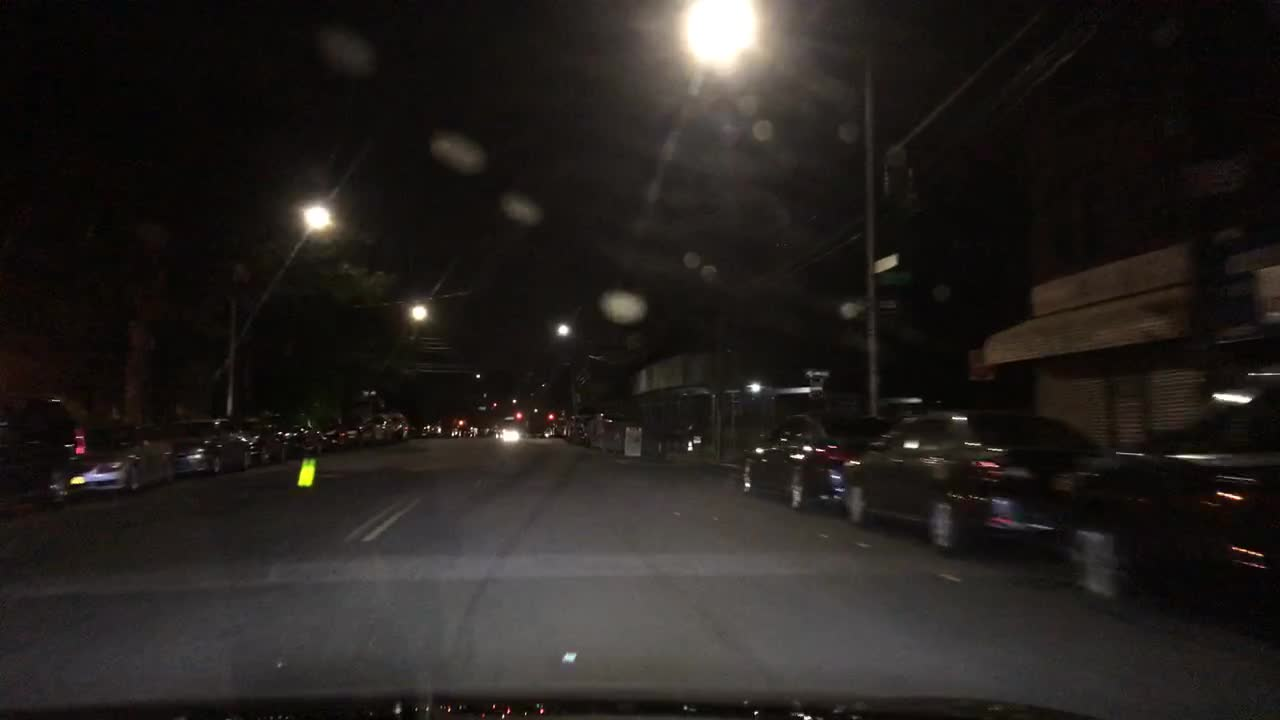

In [7]:
img = Image.open(os.path.join(image_train, name))
img

In [8]:
json_train

person = 0
vehicle = 0
all_categories = {}

dir = os.listdir(json_train)

for i in range(len(dir)):
    j = json.load(open(os.path.join(json_train, dir[i])))
    # print(json.dumps(j, indent=4))
    for obj in j["frames"]:
        # print(f"obj type {type(obj)}: {obj}")
        if "objects" in obj:
            for o in obj["objects"]:
                # print(f"o: {o}")
                if o['category'] in all_categories.keys():
                    all_categories[o["category"]] += 1
                else:
                    all_categories[o["category"]] = 1
    if i % 5000 == 0:
        print(f"Processed {i} files")
    
    
                
    # break
#     print(j)
#     for obj in j["labels"]:
        
#         all_categories.append(obj["category"])
#         break
# print(f"All categories: {set(all_categories)}")
    
    
    # for obj in j["labels"]:
    #     if obj["category"] == "person":
    #         person += 1
    #     elif obj["category"].startswith("vehicle"):
    #         vehicle += 1

print(all_categories)


Processed 0 files
Processed 5000 files
Processed 10000 files
Processed 15000 files
Processed 20000 files
Processed 25000 files
Processed 30000 files
Processed 35000 files
Processed 40000 files
Processed 45000 files
Processed 50000 files
Processed 55000 files
Processed 60000 files
Processed 65000 files
{'traffic sign': 239961, 'traffic light': 186301, 'car': 714121, 'area/drivable': 64050, 'lane/road curb': 109868, 'lane/double yellow': 37519, 'truck': 30012, 'bus': 11688, 'area/alternative': 61799, 'lane/single yellow': 20220, 'lane/single white': 247108, 'person': 91435, 'lane/crosswalk': 108284, 'rider': 4522, 'bike': 7227, 'lane/single other': 249, 'lane/double white': 5674, 'motor': 3002, 'train': 136, 'area/unknown': 2, 'lane/double other': 26}


In [9]:
print(j.keys())

print(f"name: {j['name']}")
print(f'frames: {j["frames"]}')
print(f'len frames: {len(j["frames"])}')
print(j["frames"][0].keys())

print(j["frames"][0]["objects"][0].keys())
print(len(j["frames"][0]["objects"]))
print(len(j["frames"][0]["objects"][0]))
print(j["frames"][0]["objects"][0])
print(j["frames"][0]["objects"])


roads = [obj for obj in j["frames"][0]["objects"] if obj["category"] == "area/drivable"]
roads

dict_keys(['name', 'frames', 'attributes'])
name: 1fe1d720-9bec2d46
frames: [{'timestamp': 10000, 'objects': [{'category': 'car', 'id': 0, 'attributes': {'occluded': False, 'truncated': True, 'trafficLightColor': 'none'}, 'box2d': {'x1': 0.019137, 'y1': 349.339338, 'x2': 162.672383, 'y2': 422.827248}}, {'category': 'car', 'id': 1, 'attributes': {'occluded': True, 'truncated': False, 'trafficLightColor': 'none'}, 'box2d': {'x1': 145.035286, 'y1': 360.117565, 'x2': 193.047388, 'y2': 410.089343}}, {'category': 'car', 'id': 2, 'attributes': {'occluded': False, 'truncated': False, 'trafficLightColor': 'none'}, 'box2d': {'x1': 402.7329, 'y1': 351.299016, 'x2': 521.293399, 'y2': 429.686122}}, {'category': 'car', 'id': 3, 'attributes': {'occluded': True, 'truncated': False, 'trafficLightColor': 'none'}, 'box2d': {'x1': 506.595816, 'y1': 358.157887, 'x2': 554.607921, 'y2': 416.948216}}, {'category': 'car', 'id': 4, 'attributes': {'occluded': True, 'truncated': False, 'trafficLightColor': 'none'

[{'category': 'area/drivable',
  'id': 21,
  'attributes': {},
  'poly2d': [[597.944109, 398.587221, 'L'],
   [525.381659, 439.087193, 'L'],
   [242.631932, 433.535249, 'L'],
   [153.570379, 436.606337, 'C'],
   [82.935355, 438.141881, 'C'],
   [0, 423.899704, 'C'],
   [0, 621.337067, 'L'],
   [434.256723, 550.462116, 'C'],
   [901.693902, 604.462079, 'C'],
   [1280.811619, 628.087062, 'C'],
   [1280.811619, 574.087101, 'L'],
   [1062.006291, 511.649643, 'L'],
   [786.94398, 511.649643, 'L'],
   [732.470469, 474.994937, 'L'],
   [735.541557, 424.321985, 'L'],
   [672.194059, 400.27472, 'L'],
   [597.944109, 398.587221, 'L']]}]

In [10]:
objects = j["frames"][0]["objects"]

roads = [obj for obj in objects if obj["category"] == "area/drivable"]
lanes = [obj for obj in objects if obj["category"].startswith("lane/")]
person = [obj for obj in objects if obj["category"] == "person"]
road_all = [
    obj for obj in objects if "area" in obj["category"] or "lane" in obj["category"]
]

print(f"Drivable areas : {len(roads)}")
print(f"Lane markings  : {len(lanes)}")
print(f"Pedestrians    : {len(person)}")
print(f"All road objs  : {len(road_all)}")
print()
print("Roads:", roads)
print()
print("Lanes:", lanes)

Drivable areas : 1
Lane markings  : 12
Pedestrians    : 1
All road objs  : 13

Roads: [{'category': 'area/drivable', 'id': 21, 'attributes': {}, 'poly2d': [[597.944109, 398.587221, 'L'], [525.381659, 439.087193, 'L'], [242.631932, 433.535249, 'L'], [153.570379, 436.606337, 'C'], [82.935355, 438.141881, 'C'], [0, 423.899704, 'C'], [0, 621.337067, 'L'], [434.256723, 550.462116, 'C'], [901.693902, 604.462079, 'C'], [1280.811619, 628.087062, 'C'], [1280.811619, 574.087101, 'L'], [1062.006291, 511.649643, 'L'], [786.94398, 511.649643, 'L'], [732.470469, 474.994937, 'L'], [735.541557, 424.321985, 'L'], [672.194059, 400.27472, 'L'], [597.944109, 398.587221, 'L']]}]

Lanes: [{'category': 'lane/crosswalk', 'id': 22, 'attributes': {'direction': 'vertical', 'style': 'dashed'}, 'poly2d': [[249.394738, 432.284213, 'L'], [740.51053, 439.957897, 'L']]}, {'category': 'lane/crosswalk', 'id': 23, 'attributes': {'direction': 'vertical', 'style': 'dashed'}, 'poly2d': [[333.805265, 423.331581, 'L'], [405.4

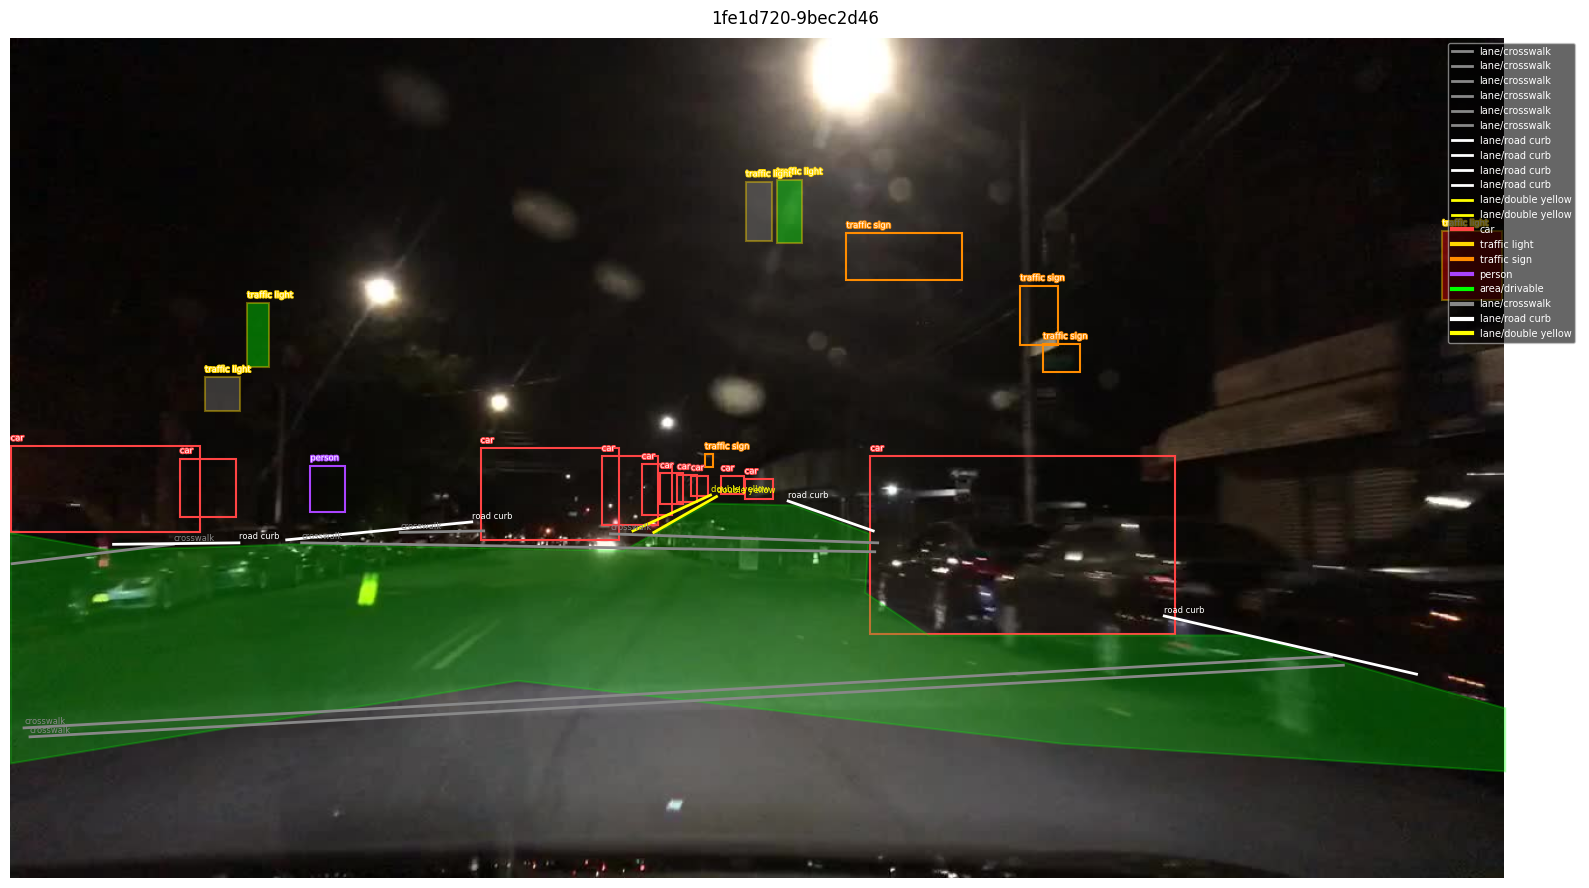

In [11]:
# Color map per category
COLORS = {
    "car": "#FF4444",
    "traffic light": "#FFD700",
    "traffic sign": "#FF8C00",
    "person": "#AA44FF",
    "rider": "#FF44AA",
    "truck": "#4444FF",
    "bus": "#00AAFF",
    "bike": "#00FFAA",
    "motor": "#FF6600",
    "area/drivable": "#00FF00",
    "lane/road curb": "#FFFFFF",
    "lane/double yellow": "#FFFF00",
    "lane/single white": "#CCCCCC",
}
DEFAULT_COLOR = "#888888"

TRAFFIC_LIGHT_COLORS = {
    "red": "red",
    "green": "lime",
    "yellow": "yellow",
    "none": "gray",
}

fig, ax = plt.subplots(1, 1, figsize=(16, 9))
ax.imshow(img)
ax.axis("off")
ax.set_title(j["name"], fontsize=12, pad=10)

for obj in objects:
    cat = obj["category"]
    color = COLORS.get(cat, DEFAULT_COLOR)

    # --- Bounding box objects (cars, traffic signs, lights, etc.) ---
    if "box2d" in obj:
        b = obj["box2d"]
        x1, y1, x2, y2 = b["x1"], b["y1"], b["x2"], b["y2"]
        w, h = x2 - x1, y2 - y1

        # For traffic lights, use the signal color as fill
        if cat == "traffic light":
            sig_color = TRAFFIC_LIGHT_COLORS.get(
                obj["attributes"].get("trafficLightColor", "none"), "gray"
            )
            rect = patches.Rectangle(
                (x1, y1),
                w,
                h,
                linewidth=1.5,
                edgecolor=color,
                facecolor=sig_color,
                alpha=0.4,
            )
        else:
            rect = patches.Rectangle(
                (x1, y1), w, h, linewidth=1.5, edgecolor=color, facecolor="none"
            )
        ax.add_patch(rect)

        # Label
        label = cat.split("/")[-1]
        txt = ax.text(x1, y1 - 3, label, fontsize=6, color="white", va="bottom")
        txt.set_path_effects([pe.withStroke(linewidth=1.5, foreground=color)])

    # --- Polygon objects (drivable area, lanes) ---
    elif "poly2d" in obj:
        pts = [(p[0], p[1]) for p in obj["poly2d"]]
        if len(pts) < 2:
            continue
        xs, ys = zip(*pts)

        if cat == "area/drivable":
            poly = patches.Polygon(
                list(zip(xs, ys)),
                closed=True,
                edgecolor=color,
                facecolor=color,
                alpha=0.25,
                linewidth=1.5,
            )
            ax.add_patch(poly)
        else:
            # Lanes: just draw the line
            ax.plot(xs, ys, color=color, linewidth=2, label=cat)
            ax.text(xs[0], ys[0] - 3, cat.split("/")[-1], fontsize=6, color=color)

# Legend (deduplicated)
seen = set()
for obj in objects:
    cat = obj["category"]
    if cat not in seen:
        color = COLORS.get(cat, DEFAULT_COLOR)
        ax.plot([], [], color=color, linewidth=3, label=cat)
        seen.add(cat)
ax.legend(
    loc="upper right", fontsize=7, framealpha=0.6, facecolor="black", labelcolor="white"
)

plt.tight_layout()
plt.show()

In [25]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("manideep1108/tusimple")

print("Path to dataset files:", path)

/Users/amannindra/miniconda3/envs/Lannet310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 21.6G/21.6G [07:16<00:00, 53.2MB/s]  

Extracting files...


Path to dataset files: /Users/amannindra/.cache/kagglehub/datasets/manideep1108/tusimple/versions/5


In [25]:
model = deeplabv3_resnet50(progress = True)
model

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [26]:
iter = 2
max_iter = 10
power = 0.9
learning_rate = math.pow((1 - iter/max_iter), power)
crop = 512
batch_size = 16
output_stride = 16
decay = 0.9997

# data augmentation
# randomly scaling input images from 0.5 to 2
# and random left-right flipping during training

In [27]:
model.eval()

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [ ]:
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = preprocess(img)

input_batch = input_tensor.unsqueeze(0) 
    input_batch = input_batch.to('cuda')
    model.to('cuda')

with torch.no_grad():
    output = model(input_batch)['out'][0]
output_predictions = output.argmax(0)


In [25]:
output_predictions

tensor([[ 2,  2,  2,  ..., 10, 10, 10],
        [ 2,  2,  2,  ..., 10, 10, 10],
        [ 2,  2,  2,  ..., 10, 10, 10],
        ...,
        [10, 10, 10,  ..., 10, 10, 10],
        [10, 10, 10,  ..., 10, 10, 10],
        [10, 10, 10,  ..., 10, 10, 10]])

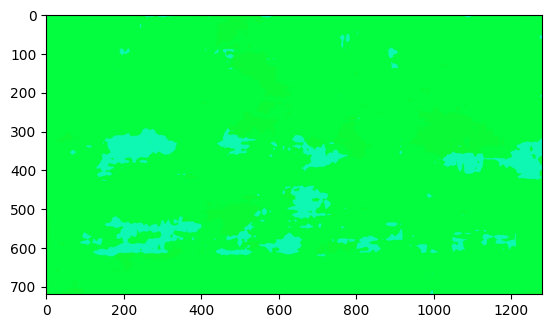

In [26]:
palette = torch.tensor([2 ** 25 - 1, 2 ** 15 - 1, 2 ** 21 - 1])
colors = torch.as_tensor([i for i in range(21)])[:, None] * palette
colors = (colors % 255).numpy().astype("uint8")

# plot the semantic segmentation predictions of 21 classes in each color
r = Image.fromarray(output_predictions.byte().cpu().numpy()).resize(img.size)
r.putpalette(colors)

import matplotlib.pyplot as plt
plt.imshow(r)